# T06 — Animations

## What this notebook produces

Three animations, all driven by **pyGMT** for the per-frame rendering and `ffmpeg` (via `subprocess`) for the cross-platform MP4 encoding.

1. **`plate_motion.gif`** — quick-look animated GIF of the global Zahirovic 2022 reconstruction from 250 Ma to 0 Ma. Assembled with `imageio` for trivial drop-in to a README / Slack / Twitter.
2. **`plate_motion.mp4`** — same content, encoded as a cross-platform H.264 MP4 (libx264 + yuv420p + faststart). Plays on QuickTime, Windows Media, every modern browser.
3. **`litho_thickness.mp4`** — a rotating-globe view of global lithospheric thickness from Afonso et al. (2019, *GJI* [doi:10.1093/gji/ggz094](https://doi.org/10.1093/gji/ggz094)), draped on an orthographic projection. **East–West rotation** around the polar axis: viewing longitude sweeps 0° → 360°. Cubehelix colour palette, white coastlines, horizontal colourbar.
4. **`litho_thickness_reconstructed.mp4`** — the same Afonso 2019 lithospheric-thickness grid, but this time **reconstructed through deep time** using GPlately. We build a `gplately.Raster`, partition it with Zahirovic 2022 static polygons, and apply each plate's finite rotation to roll the grid back to its paleo-position at every 2-Myr step from 0 to 60 Ma. Robinson global view, dem4 CPT, reconstructed coastlines overlaid in white at each frame's age.

## Preview frames

Each video section starts with a *preview* — one representative frame rendered inline via `fig.show()`. That lets you sanity-check the recipe (palette, projection, shading, coastline weight) before committing to the full save-loop + ffmpeg encode. Each render loop simply re-calls the same helper function used by the preview, so whatever you see in the preview is what every frame in the MP4 looks like.

## A note on `gmt movie`

GMT itself ships a `movie` module with built-in time labels, progress bars and fade in/out. pyGMT does **not** yet wrap it as a `Figure` method ([upstream issue #364](https://github.com/GenericMappingTools/pygmt/issues/364)) — the canonical Python pattern is to drive it via `subprocess.run(['gmt', 'movie', main_script, …])` exactly the same way we drive ffmpeg below. For the four output files in this notebook we stay in pure pyGMT for the frame rendering (which keeps you inside the Python ecosystem) and use ffmpeg for the MP4 encoding.

**Audience**: both.  
**Difficulty**: ★★☆.  
**Runtime**: ≈5 minutes for all four output files at 720p.

## Learning objectives

- Drive a deep-time animation loop with `gplately` + pyGMT, writing one frame per reconstruction step.
- Use ffmpeg to stitch frames into an mp4 video.
- Pick sensible frame intervals (5–10 Myr) for smooth playback without exploding the runtime.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Time range**: 0–150 Ma in 10 Myr steps (16 frames).
- **Python**: `gplately`, `pygmt`, `pygplates`, `imageio` (optional for mp4 assembly).
- **External**: `ffmpeg` on PATH if writing mp4.
- **Runtime**: ~2 minutes for the default frame set.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import subprocess
from pathlib import Path
import numpy as np
import xarray as xr
import gplately
import pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Suite-wide tutorial style: bigger panel titles.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

FRAMES_PMM       = Path("./pmm_frames");          FRAMES_PMM.mkdir(exist_ok=True)
FRAMES_AGE_ROT   = Path("./age_rot_frames");      FRAMES_AGE_ROT.mkdir(exist_ok=True)
FRAMES_AGE_TIME  = Path("./age_time_frames");     FRAMES_AGE_TIME.mkdir(exist_ok=True)
VIDEOS           = Path("./videos");              VIDEOS.mkdir(exist_ok=True)

# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
TIME_START_MA        = 250.0         # Ma — beginning of animation
TIME_END_MA          = 0.0           # Ma — end of animation
TIME_STEP_MA         = 5.0           # Ma — frame cadence
ANCHOR_PLATE_ID      = 0
# ============================================================================


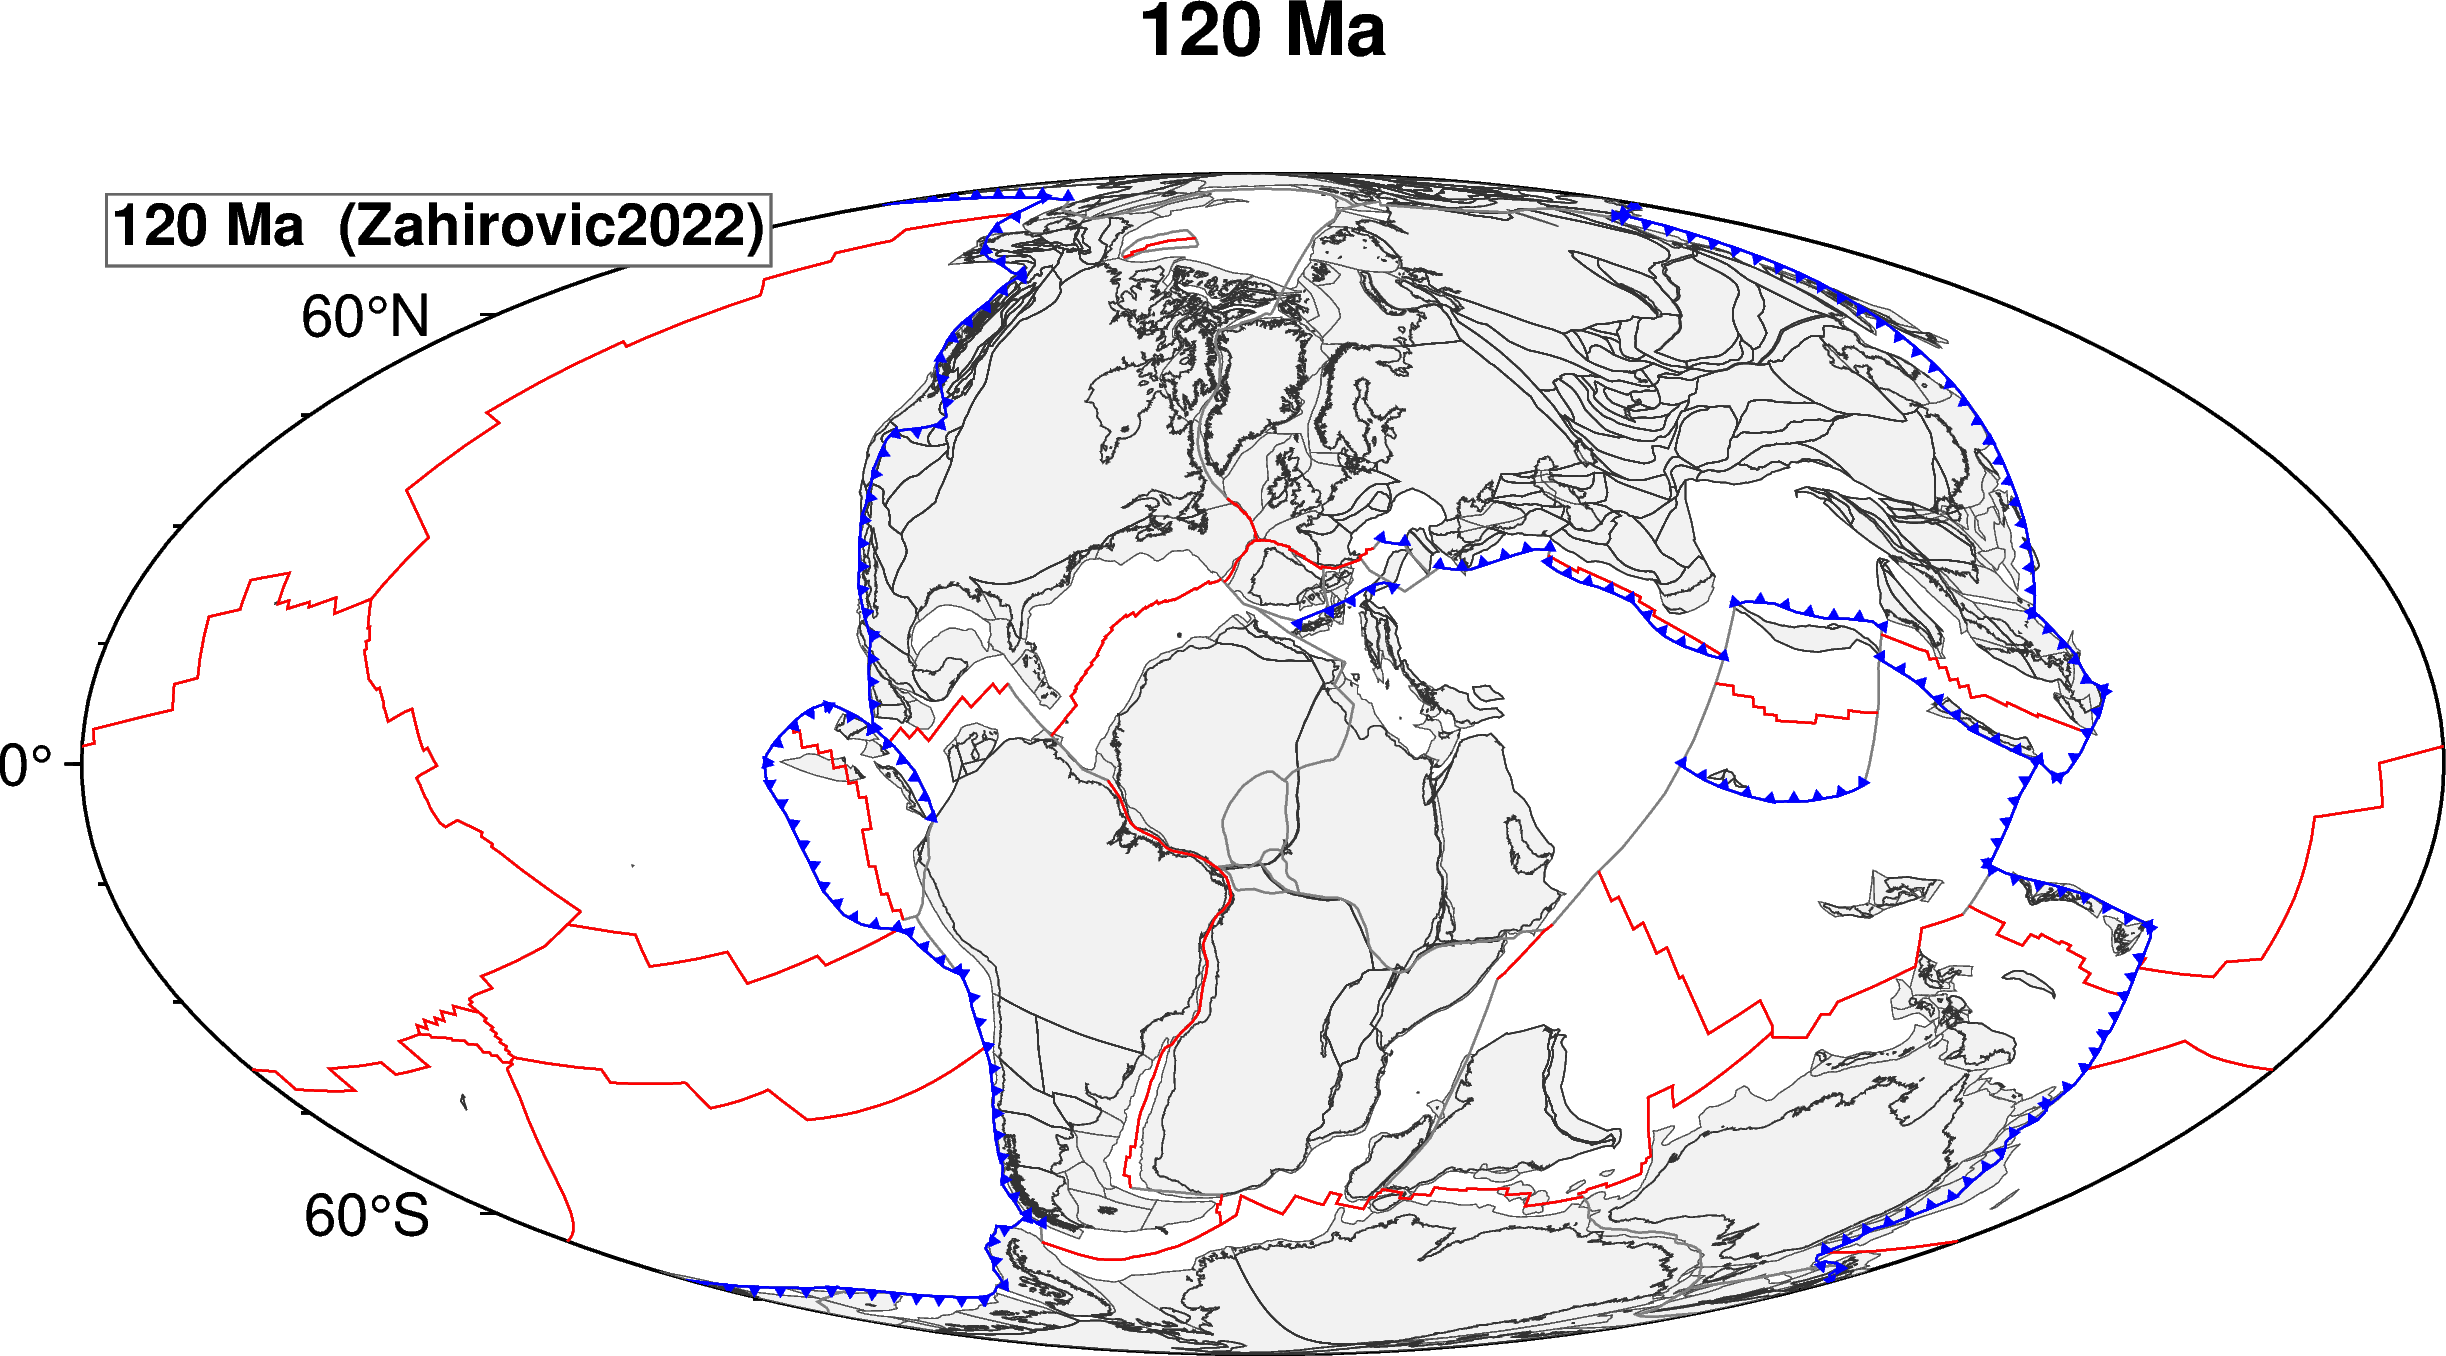

In [3]:
# Cell 2 — plate-motion setup + preview frame
#
# Factor the per-frame rendering into a helper so we can use it for
# (1) one preview frame shown inline below and (2) the save-loop in
# the next cell. Naming convention: frame_0000.png is the FIRST
# (oldest) frame — alphabetical order then equals chronological order
# from past → present, which is what ffmpeg expects for the right
# playback direction.
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

def render_pmm_frame(t):
    """Render one plate-motion frame at reconstruction time `t` (Ma)."""
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=t,
        plot_engine=gplately.PygmtPlotEngine(),
        )
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/20c",
                frame=["af", f'+t{t} Ma'])
    gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray30")
    gplot.plot_coastlines(fig, pen="0.3p,gray20")
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
    gplot.plot_ridges(fig, pen="0.5p,red")
    (_tl, _tr) = gplot.get_subduction_direction()
    gplot.plot_subduction_teeth(fig, color="blue")
    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    return fig

# Preview: one frame at 120 Ma (mid-Cretaceous, classic Pangaea-breakup state)
preview_pmm = render_pmm_frame(120)
preview_pmm.show(width=700)
display(HTML('<div style="height:1cm"></div>'))

In [4]:
# Cell 2b — render all 51 plate-motion frames + encode MP4
START, END, STEP = 250, 0, 5    # Ma
for i, t in enumerate(range(START, END - 1, -STEP)):
    fig = render_pmm_frame(t)
    fig.savefig(FRAMES_PMM / f"frame_{i:04d}.png", dpi=120)
    print(f"  frame {i:>3}/{(START-END)//STEP}  ({t} Ma)")
print("Plate-motion frames done.")

  frame   0/50  (250 Ma)
  frame   1/50  (245 Ma)
  frame   2/50  (240 Ma)
  frame   3/50  (235 Ma)
  frame   4/50  (230 Ma)
  frame   5/50  (225 Ma)
  frame   6/50  (220 Ma)
  frame   7/50  (215 Ma)
  frame   8/50  (210 Ma)
  frame   9/50  (205 Ma)
  frame  10/50  (200 Ma)
  frame  11/50  (195 Ma)
  frame  12/50  (190 Ma)
  frame  13/50  (185 Ma)
  frame  14/50  (180 Ma)
  frame  15/50  (175 Ma)
  frame  16/50  (170 Ma)
  frame  17/50  (165 Ma)
  frame  18/50  (160 Ma)
  frame  19/50  (155 Ma)
  frame  20/50  (150 Ma)
  frame  21/50  (145 Ma)
  frame  22/50  (140 Ma)
  frame  23/50  (135 Ma)
  frame  24/50  (130 Ma)
  frame  25/50  (125 Ma)
  frame  26/50  (120 Ma)
  frame  27/50  (115 Ma)
  frame  28/50  (110 Ma)
  frame  29/50  (105 Ma)
  frame  30/50  (100 Ma)
  frame  31/50  (95 Ma)
  frame  32/50  (90 Ma)
  frame  33/50  (85 Ma)
  frame  34/50  (80 Ma)
  frame  35/50  (75 Ma)
  frame  36/50  (70 Ma)
  frame  37/50  (65 Ma)
  frame  38/50  (60 Ma)
  frame  39/50  (55 Ma)
  frame  

## 3. Quick-look GIF with `imageio`

Drop-in for a README or a Slack thread. Not compressed efficiently (each frame is a full image) so the file is large — use MP4 for anything bigger than ≈50 frames.

In [5]:
# Cell 3 — assemble GIF
import imageio.v3 as iio
from PIL import Image

GIF_OUT = VIDEOS / "plate_motion.gif"
frames = sorted(FRAMES_PMM.glob("frame_*.png"))   # 250 Ma → 0 Ma order

# pyGMT's tight crop produces frames with slightly different sizes from
# one t to the next (the visible boundary network changes shape).
# imageio.imwrite ends up calling np.stack which needs identical shapes,
# so pad every frame to a common (max_w, max_h) with a white background
# before stitching.
opened = [Image.open(p).convert("RGB") for p in frames]
max_w = max(im.size[0] for im in opened)
max_h = max(im.size[1] for im in opened)

padded = []
for im in opened:
    canvas = Image.new("RGB", (max_w, max_h), color="white")
    canvas.paste(im, ((max_w - im.size[0]) // 2, (max_h - im.size[1]) // 2))
    padded.append(canvas)

iio.imwrite(GIF_OUT,
            [np.array(im) for im in padded],
            duration=120, loop=0)
print(f"Wrote {GIF_OUT}  ({GIF_OUT.stat().st_size / 1e6:.1f} MB, "
      f"padded to {max_w}×{max_h})")

Wrote videos/plate_motion.gif  (3.0 MB, padded to 979×543)


## 4. Cross-platform MP4 with `ffmpeg`

Key encoder flags (the same trio is used for all three MP4s in this notebook):

- `-c:v libx264` — H.264 video codec, available on every platform.
- `-pix_fmt yuv420p` — the pixel format every consumer player supports (QuickTime, Windows Media, browsers). Without this flag ffmpeg often defaults to `yuv444p`, which plays in some browsers but not in QuickTime.
- `-movflags +faststart` — moves the metadata to the head of the file so the MP4 can stream over the web.

In [6]:
# Cell 4 — plate motion: encode as cross-platform MP4
def encode_mp4(frames_dir: Path, out: Path, framerate: int = 10) -> None:
    '''Encode every frame_*.png in `frames_dir` as a cross-platform MP4.

    The `-vf pad=ceil(iw/2)*2:ceil(ih/2)*2` filter rounds odd-numbered
    frame dimensions up to the next even pixel — libx264 + yuv420p
    requires even width AND height, and pyGMT's tight bounding-box
    crop sometimes produces odd dims (e.g. 619×713) that would
    otherwise make ffmpeg bail with returncode 1.
    '''
    cmd = [
        "ffmpeg", "-y",
        "-framerate", str(framerate),
        "-pattern_type", "glob",
        "-i", str(frames_dir / "frame_*.png"),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2:color=white",
        "-movflags", "+faststart",
        "-crf", "20",
        str(out),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("ffmpeg failed — last 2 KB of stderr:\n")
        print(result.stderr[-2000:])
        raise subprocess.CalledProcessError(
            result.returncode, cmd, result.stdout, result.stderr)
    print(f"Wrote {out}  ({out.stat().st_size / 1e6:.1f} MB)")

encode_mp4(FRAMES_PMM, VIDEOS / "plate_motion.mp4", framerate=10)

Wrote videos/plate_motion.mp4  (2.4 MB)


## 5. Seafloor age grid — rotating-globe animation

PMM ships a synthetic seafloor age grid as part of every plate model. Loading the Zahirovic 2022 grid at the present day with `model.get_raster("AgeGrids", time=0)` gives us a global raster of oceanic-crust age. We render it as a rotating orthographic globe: viewing longitude sweeps **0° → 360°** in 5° steps over 72 frames.

Recipe per frame:

1. `pygmt.makecpt(cmap="hawaii", series=[0, 280, 5], reverse=True)` — diverging blue-cyan-yellow palette; young ridges in yellow, old crust in blue.
2. `fig.grdimage(age_grid, projection=f"G{lon}/0/12c", region="g", cmap=True)`
3. `fig.coast(land="gray80", shorelines="0.3p,white")` — present-day continents on top.
4. `fig.colorbar(...)` — horizontal bar below the globe.
5. `fig.savefig(...)`.

The choice of seafloor age as the demonstration raster gives a clean coupling to the rest of the suite: animation 3 below shows the same grid evolving through deep time, and animations are entirely Zahirovic 2022 — no external dependency.


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


Seafloor age (Zahirovic 2022, t=0): 0 … 339 Ma


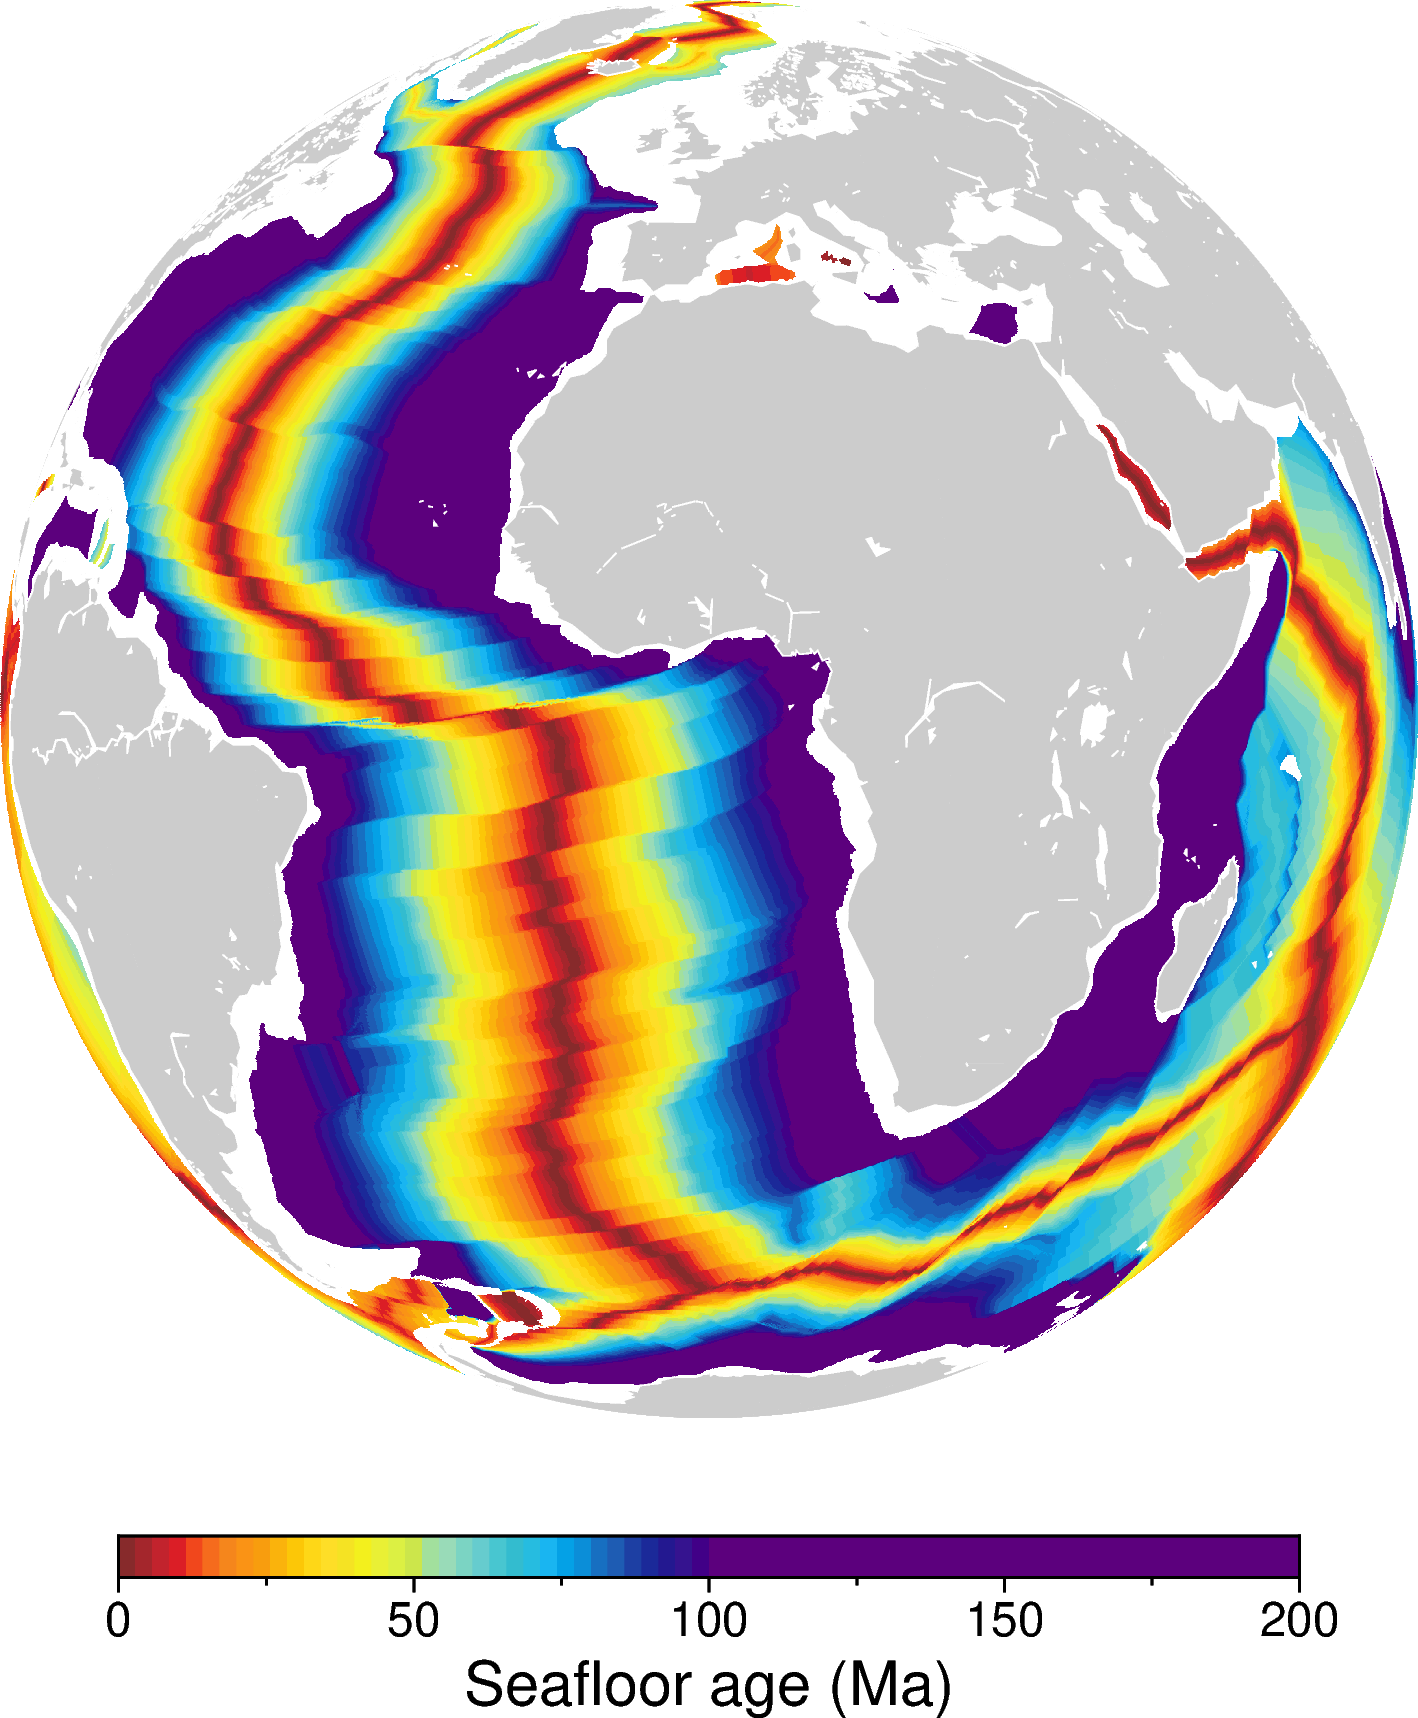

In [7]:
# Cell 5 — seafloor-age rotating-globe setup + preview frame
# Load Zahirovic 2022's present-day seafloor age grid via PMM. The grid
# ships with the plate model — no external download required.
age_file_0 = model.get_raster("AgeGrids", time=0)
age_now = (xr.open_dataarray(str(age_file_0))
           if str(age_file_0).endswith(".nc")
           else xr.open_dataset(str(age_file_0)).to_array().isel(variable=0))
print(f"Seafloor age (Zahirovic 2022, t=0): "
      f"{float(age_now.min()):.0f} … {float(age_now.max()):.0f} Ma")

NFRAMES_AGE_ROT = 72   # 5° viewing-longitude step

def render_age_rot_frame(lon):
    """Rotating-globe frame: view at longitude `lon`, age grid as basemap."""
    fig = pygmt.Figure()
    pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 200, 1],
                  background="o")
    fig.grdimage(age_now,
                 projection=f"G{lon:.2f}/0/12c", region="g",
                 cmap=True, nan_transparent=True)
    fig.coast(land="gray80", shorelines="0.3p,white")
    fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
                 frame="a50f25+lSeafloor age (Ma)")
    return fig

# Preview at Greenwich (lon=0°)
preview_age = render_age_rot_frame(0)
preview_age.show(width=600)
display(HTML('<div style="height:1cm"></div>'))


In [8]:
# Cell 5b — render all rotating-globe frames + encode MP4
for i in range(NFRAMES_AGE_ROT):
    lon = i * 360.0 / NFRAMES_AGE_ROT
    fig = render_age_rot_frame(lon)
    fig.savefig(FRAMES_AGE_ROT / f"frame_{i:04d}.png", dpi=130)
    print(f"  frame {i:>2}/{NFRAMES_AGE_ROT}  (lon = {lon:6.2f}°)")
encode_mp4(FRAMES_AGE_ROT, VIDEOS / "seafloor_age_rotating.mp4", framerate=6)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.
makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame  0/72  (lon =   0.00°)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame  1/72  (lon =   5.00°)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


...

  frame 68/72  (lon = 340.00°)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame 69/72  (lon = 345.00°)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame 70/72  (lon = 350.00°)
  frame 71/72  (lon = 355.00°)
Wrote videos/seafloor_age_rotating.mp4  (2.1 MB)


## 6. Seafloor age grid through deep time — 0 → 60 Ma

The rotating globe above is a pure pyGMT exercise — it shows the present-day age grid from a sequence of viewing angles, no plate-tectonic motion. To bring GPlately's reconstruction engine in, we now run through deep time: at each reconstruction age `t` from 0 to 60 Ma in 2 Myr steps, we ask PMM for the Zahirovic 2022 age grid AT that time. PMM has already partitioned each cell by plate ID and applied the right finite rotation, so the grid we get back is a complete paleo-age field — young ridges where they were at time t, masked to NaN over what is now oceanic crust that didn't yet exist.

The animation visualises Atlantic-Indian opening over the Cenozoic and India's dash north toward Eurasia, with seafloor ages colouring each pixel by how old it was AT that reconstruction time. This is the canonical reconstruction-driven animation in the suite, anchored entirely on Zahirovic 2022.


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


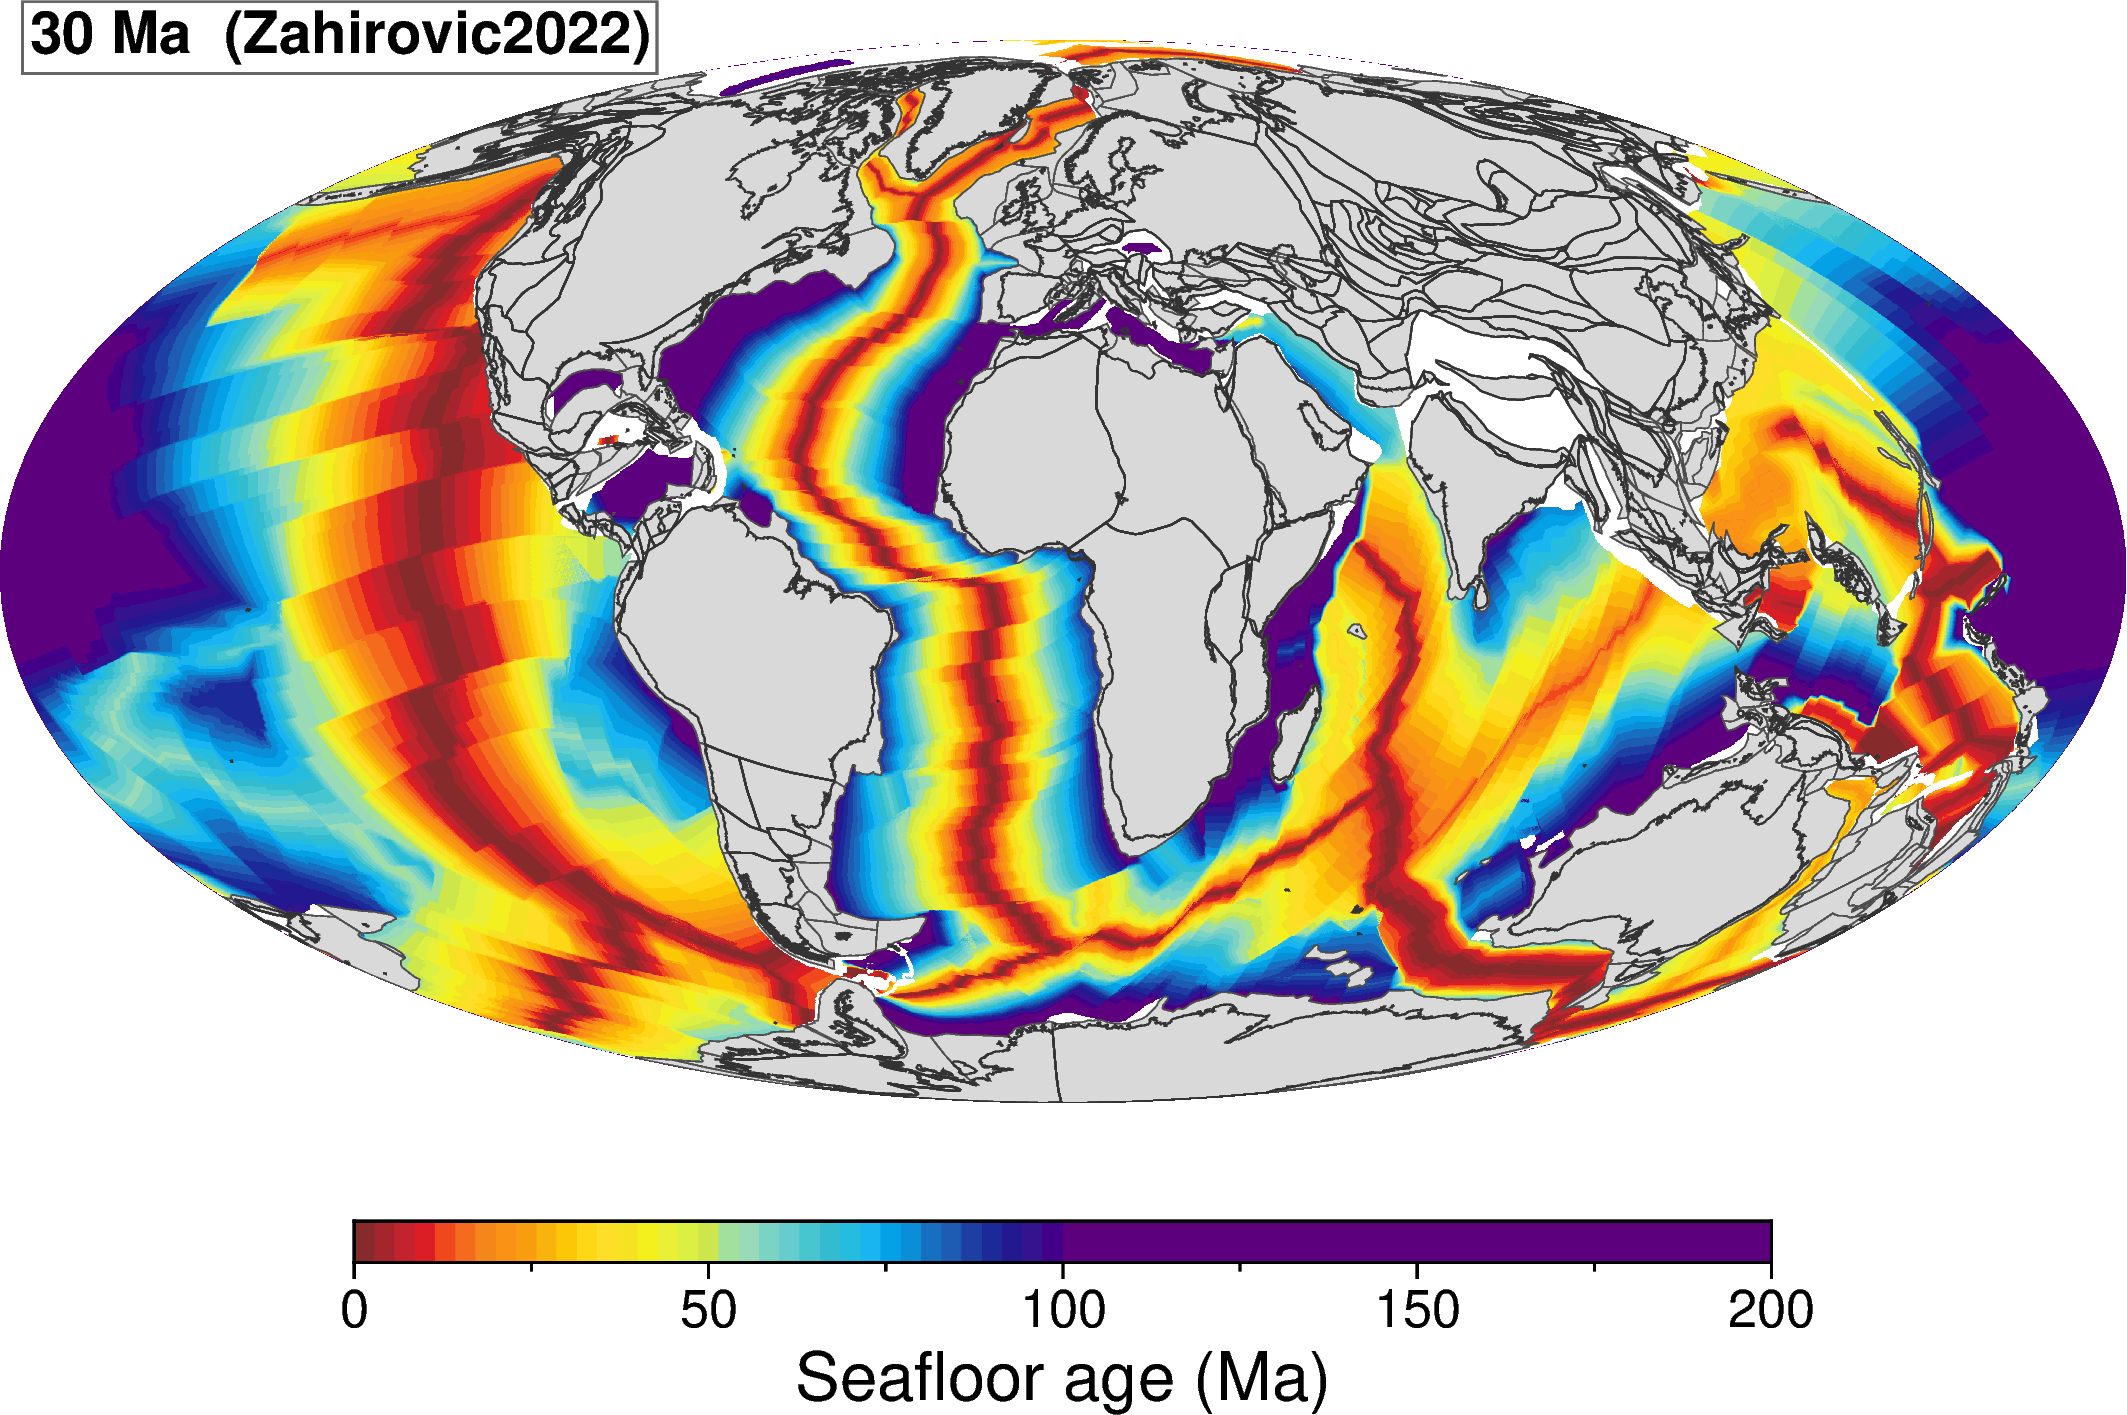

In [9]:
# Cell 7 — reconstructed seafloor age grid setup + preview frame
#
# At each reconstruction time t, PMM gives us a fresh paleo-age grid via
#   `model.get_raster("AgeGrids", time=t)`
# That grid has already had the static-polygons + per-plate rotations
# applied, so no manual Raster.reconstruct() call is needed.

# Per-frame gplot to overlay reconstructed coastlines at each time.
gplot_t = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=0,

plot_engine=gplately.PygmtPlotEngine(),
)

TIMES_AGE = list(range(0, 61, 2))   # 0, 2, 4, …, 60 Ma → 31 frames

def render_age_time_frame(t):
    """Render the Zahirovic 2022 paleo-age grid at time `t` (Ma) with
    contemporaneous coastlines overlaid."""
    age_file_t = model.get_raster("AgeGrids", time=int(t))
    age_t = (xr.open_dataarray(str(age_file_t))
             if str(age_file_t).endswith(".nc")
             else xr.open_dataset(str(age_file_t)).to_array().isel(variable=0))

    fig = pygmt.Figure()
    pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 200, 1],
                  background="o")
    fig.grdimage(age_t, projection="W0/18c", region="d",
                 cmap=True, nan_transparent=True)
    gplot_t.time = float(t)
    # Filled light-grey continents with a thin darker outline — same
    # visual idiom as the rotating-globe cell's fig.coast(land=...).
    gplot_t.plot_continents(fig, fill="gray85", pen="0.3p,gray30")
    gplot_t.plot_coastlines(fig, pen="0.4p,gray20")
    fig.colorbar(position="JBC+w12c/0.35c+h+o0/1c",
                 frame="a50f25+lSeafloor age (Ma)")
    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40", no_clip=True)
    return fig

# Preview: 30 Ma — India well underway on its dash north,
# Atlantic noticeably narrower than today.
preview_age_time = render_age_time_frame(30)
preview_age_time.show(width=700)
display(HTML('<div style="height:1cm"></div>'))


In [10]:
# Cell 7b — render all paleo-age-grid frames + encode MP4
for i, t in enumerate(TIMES_AGE):
    fig = render_age_time_frame(t)
    fig.savefig(FRAMES_AGE_TIME / f"frame_{i:04d}.png", dpi=130)
    print(f"  frame {i:>2}/{len(TIMES_AGE)}  (t = {t:>2} Ma)")
encode_mp4(FRAMES_AGE_TIME,
           VIDEOS / "seafloor_age_through_time.mp4",
           framerate=6)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame  0/31  (t =  0 Ma)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame  1/31  (t =  2 Ma)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


...

  frame 27/31  (t = 54 Ma)
  frame 28/31  (t = 56 Ma)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame 29/31  (t = 58 Ma)


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  frame 30/31  (t = 60 Ma)
Wrote videos/seafloor_age_through_time.mp4  (1.9 MB)


## What the three animations tell us

**Plate motion** — speed contrast. Some plate pairs (India–Asia, Africa–Eurasia) are spectacularly fast through the Cenozoic; others (Antarctica, the West-African craton) barely move. This visual contrast is the easiest way to build intuition for which plates are kinematically active and which are passively along for the ride.

**Lithospheric thickness** — the longest-lived signal in the lithosphere. Old cratons (West Africa, Siberia, the Canadian Shield, the Australian and Antarctic cores) glow dark (>200 km thick), while young ocean basins and active margins (East African Rift, mid-ocean ridges, the western US) read lighter (<80 km). Watch the rotation cycle past each continent to see how the thickest cores anchor every craton.

**Reconstructed lithospheric thickness (0–60 Ma)** — the cratonic roots in motion. Watch the slow march of the West-African and Australian-Antarctic cratons (dark) and the dramatic flight of India (also dark — its cratonic root is one of the thickest on Earth) as the Tethys closes. The reconstructed grid stays bound to each plate so the cratonic geometry comes along for the ride; this is the kinematic part of the lithospheric story, isolated from any thermal evolution.

## Extend this

- **Higher resolution.** Bump `dpi=130` in cells 5 / 6 to 200 and rerun. Output MP4s will be larger but visibly sharper at 1080p.
- **Combine the videos side-by-side** via `ffmpeg`'s `hstack` filter for a small demo reel.
- **Drape an age grid behind the plate-motion frames** for an "ocean-floor age" version.
- **Use `gmt movie` for the polished version** with built-in progress bar and time labels — pass the same per-frame Python logic from a main_script.sh that `subprocess`-invokes a render-one-frame Python script. See [the GMT movie docs](https://docs.generic-mapping-tools.org/latest/movie.html).

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J. & Gaina, C. (2019). A global reference model of the lithosphere and upper mantle from joint inversion of surface waves and gravity. *Geophys. J. Int.* 217, 1602-1628. https://doi.org/10.1093/gji/ggz094
- FFmpeg Developers (2024). FFmpeg multimedia framework. https://ffmpeg.org